In [1]:
#!git clone https://github.com/whyhardt/SPICE.git

In [2]:
# !pip install -e SPICE

In [3]:
import sys
import pandas as pd
import numpy as np
import torch

from spice import SpiceEstimator

sys.path.append('../../..')
from weinhardt2026.utils.benchmarking_gru import training
from benchmarking_bustamante2023 import MarginalValueTheoremModel, get_dataset, generate_behavior
from spice_bustamante2023 import SpiceModel, CONFIG

# NOTEBOOK CONFIG

In [4]:
train_spice = False
train_mvt = False
train_gru = False

## Load dataset

Let's load the data first with the `csv_to_dataset` method. This method returns a `SpiceDataset` object which we can use right away 

In [5]:
path_data = 'data/bustamante2023.csv'
test_sessions = (3, 6)

dataset_train, dataset_test, info_dataset = get_dataset(path_data=path_data, test_sessions=test_sessions, verbose=True)

Shape of dataset: torch.Size([1997, 112, 1, 11])
Number of participants: 250
Number of actions in dataset: 2
Number of additional inputs: 4


## SPICE Setup

Now we are going to define the configuration for SPICE with a `SpiceConfig` object.

The `SpiceConfig` takes as arguments 
1. `library_setup (dict)`: Defining the variable names of each module.
2. `memory_state (dict)`: Defining the memory state variables and their initial values.
3. `states_in_logit (list)`: Defining which of the memory state variables are used later for the logit computation. This is necessary for some background processes.  

And then we are going to define the SPICE model which is a child of the `BaseModel` and `torch.nn.Module` class and takes as required arguments:
1. `spice_config (SpiceConfig)`: previously defined SpiceConfig object
2. `n_actions (int)`: number of possible actions in your dataset (including non-displayed ones if applicable).
3. `n_participants (int)`: number of participants in your dataset.

As usual for a `torch.nn.Module` we have to define at least the `__init__` method and the `forward` method.
The `forward` method gets called when computing a forward pass through the model and takes as inputs `(inputs (SpiceDataset.xs), prev_state (dict, default: None), batch_first (bool, default: False))` and returns `(logits (torch.Tensor, shape: (n_participants*n_blocks*n_experiments, timesteps, n_actions)), updated_state (dict))`. Two necessary method calls inside the forward pass are:
1. `self.init_forward_pass(inputs, prev_state) -> SpiceSignals`: returns a `SpiceSignals` object which carries all relevant information already processed.
2. `self.post_forward_pass(SpiceSignals, batch_first) -> SpiceSignals`: does some re-arranging of the logits to adhere to `batch_first`.

## SPICE Training

In [6]:
path_spice = 'params/spice_bustamante2023.pkl'

estimator = SpiceEstimator(
        # model paramaeters
        spice_class=SpiceModel,
        spice_config=CONFIG,
        n_actions=dataset_train.n_actions,
        n_participants=dataset_train.n_participants,
        
        epochs=1000,
        warmup_steps=250,
        
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
        verbose=True,
        save_path_spice=path_spice,
    )

In [7]:
if train_spice:
    estimator.fit(dataset_train.xs, dataset_train.ys, dataset_train.xs, dataset_train.ys)

In [8]:
estimator.load_spice(path_spice)

In [9]:
# Print example SPICE model for first participant
print("\nExample SPICE model (participant 0):")
estimator.print_spice_model(participant_id=0)


Example SPICE model (participant 0):
reward_environment[t+1]      = -0.231 1 + 0.419 reward_environment[t] + 0.79 reward[t] + -0.13 reward_environment^2 + 0.645 reward_environment*reward[t] + 1.481 reward[t]^2 
reward_patch_harvest[t+1]    = -0.503 1 + 1.085 reward_patch_harvest[t] + 0.054 reward_patch_harvest^2 + 0.056 reward_patch_harvest*reward[t] + 0.547 reward[t]^2 
reward_patch_exit[t+1]       = 0.113 1 + 0.537 reward_patch_exit[t] + 0.108 reward_patch_exit^2 
depletion_patch_harvest[t+1] = 0.281 1 + 0.729 depletion_patch_harvest[t] + 0.435 dreward[t] + -0.023 depletion_patch_harvest^2 + 0.996 depletion_patch_harvest*dreward[t] 
depletion_patch_exit[t+1]    = 2.006 1 + 1.0 depletion_patch_exit[t] + 0.237 depletion_patch_exit^2 
continuation_patch[t+1]      = -0.035 1 + 1.0 continuation_patch[t] + 0.119 action[t-1] + -0.17 continuation_patch*action[t-1] + 0.119 action[t-1]^2 


## Benchmarking

### MVT Model by Constantino et al. (2015)

In [10]:
# 1. stick to low effort 
# 2. two sets of params for low and high effort

mvt = MarginalValueTheoremModel(
    n_participants=dataset_train.n_participants,
    depletion=None,  # if None: learn value; else: fix to given value;
    baseline_gain=None,  # if None: learn value; else: fix to given value;
    batch_first=True,
    )

path_mvt = path_spice.replace('spice_', 'mvt_')

In [11]:
if train_mvt:
    epochs = 1000
    optimizer = torch.optim.Adam(params=mvt.parameters(), lr=0.01)

    mvt = training(
        model=mvt,
        optimizer=optimizer,
        epochs=epochs,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        device=torch.device('cpu'),
    )

    torch.save(mvt.state_dict(), path_mvt)

In [12]:
mvt.load_state_dict(torch.load(path_mvt, map_location='cpu'))

<All keys matched successfully>

### GRU Model

In [13]:
from weinhardt2026.utils.benchmarking_gru import GRUModel

gru = GRUModel(dataset_train.n_actions)

path_gru = path_spice.replace('spice_', 'gru_')

In [14]:
if train_gru:
    epochs = 1000
    optimizer = torch.optim.Adam(gru.parameters(), lr=0.01)

    gru = training(
        model=gru,
        optimizer=optimizer,
        dataset_train=dataset_train,
        dataset_test=dataset_test,
        epochs=epochs,
        ).to(torch.device('cpu'))

    torch.save(gru.state_dict(), path_gru)

In [15]:
gru.load_state_dict(torch.load(path_gru, map_location='cpu'))

<All keys matched successfully>

# ANALYSIS

In [16]:
from weinhardt2026.analysis.analysis_model_evaluation import analysis_model_evaluation
from weinhardt2026.analysis.analysis_coefficients_distributions import analysis_coefficients_distributions
from weinhardt2026.analysis.analysis_coefficients_individuals import analysis_coefficients_individuals

## General analysis

In [17]:
df = pd.read_csv(path_data)
df['last_reward'] = df.groupby('subject_id')['last_reward'].fillna(method='bfill')
df['participant_id'] = pd.factorize(df['subject_id'])[0]
exit_df = df[df['decision'] == 1]
mean_exit_threshold = exit_df.groupby(['participant_id', 'subject_id'])['last_reward'].mean().reset_index()
mean_exit_threshold['relative_optimal'] = mean_exit_threshold['last_reward'] - 6.78 #from Bustamante et al. Table S7, experiment 1
mean_exit_threshold['over_harvester'] = np.where(mean_exit_threshold['relative_optimal'] <= 0, 1, 0)
print(mean_exit_threshold)
overharvesters = mean_exit_threshold[mean_exit_threshold['over_harvester'] == 1]['participant_id'].unique()
underharvesters = mean_exit_threshold[mean_exit_threshold['over_harvester'] == 0]['participant_id'].unique()

print('OVERHARVESTERS') 
for p in overharvesters:
    print('Participant number', p)
    estimator.print_spice_model(participant_id=p)

print('UNDERHARVESTERS') 
for p in underharvesters:
    print('Participant number', p)
    estimator.print_spice_model(participant_id=p)

     participant_id                subject_id  last_reward  relative_optimal  \
0                 0  08aiu2bm6t15qij5826jxz50     8.241283          1.461283   
1                 1  09j932f828pn7h7bozp9mpnl     5.344722         -1.435278   
2                 2  0ax9htcbhfi3ncsospqzwjx2     8.945571          2.165571   
3                 3  0e6zivqly335lojgb4c6606t     7.554696          0.774696   
4                 4  0fawro1pivqnh4lem4ayf4o0     3.089682         -3.690318   
..              ...                       ...          ...               ...   
245             245  fzllq0yp08zefacpmy7dqq0u     9.041866          2.261866   
246             246  g2n23l2w8uf3brbllm4sbrcx     8.106489          1.326489   
247             247  g9wqksieqbldodjoyuci048q     6.765186         -0.014814   
248             248  garkh3hmuozi9loxpee54z20     7.720383          0.940383   
249             249  gd6af6pqeo2d0x2dcumwirmy     3.908357         -2.871643   

     over_harvester  
0                

In [18]:
print("Fitted MVT parameters:")
print("\nAlpha")
print(mvt.alpha_env)
print("\nBeta")
print(mvt.beta)
print("\nC")
print(mvt.c)
print("\nBaseline Gain")
print(mvt.baseline_gain)
print("\nDepletion")
print(mvt.depletion)

Fitted MVT parameters:

Alpha
tensor([0.3417, 0.1321, 0.3738, 0.2696, 0.0100, 0.2719, 0.2292, 0.0793, 0.0100,
        0.5810, 0.0423, 0.2703, 0.0663, 0.1134, 0.1278, 0.9587, 0.3526, 0.2343,
        0.3686, 0.2005, 0.0584, 0.5458, 0.9520, 0.2021, 0.3010, 0.1209, 0.0100,
        0.1839, 0.6221, 0.9701, 0.0443, 0.2997, 0.1583, 0.0100, 0.2081, 0.1094,
        0.0100, 0.0100, 0.1345, 0.2418, 0.2445, 0.9766, 0.3006, 0.0452, 0.1000,
        0.1422, 0.1899, 0.0100, 0.2942, 0.0100, 0.2017, 0.1014, 0.4381, 0.3999,
        0.0512, 0.3871, 0.3124, 0.2217, 0.6521, 0.0100, 0.6817, 0.2099, 0.3378,
        0.5072, 0.5358, 0.8913, 0.1772, 0.3155, 0.0428, 0.2561, 0.1152, 0.0100,
        0.1202, 0.0100, 0.1924, 0.0449, 0.3449, 0.1735, 0.1637, 0.0100, 0.1793,
        0.1905, 0.0524, 0.6157, 0.2093, 0.4368, 0.1283, 0.2282, 0.4504, 0.2589,
        0.1550, 0.4011, 0.1302, 0.1048, 0.3062, 0.0884, 0.4548, 0.0660, 0.3317,
        0.1296, 0.0861, 0.1337, 0.3310, 0.0695, 0.1078, 0.1637, 0.2931, 0.3172,
        0.

## Analysis model evaluation

In [19]:
analysis_model_evaluation(
    dataset=dataset_train,
    spice_model=estimator,
    benchmark_model=mvt.to(torch.device('cpu')),
    gru_model=gru.to(torch.device('cpu')),
)

Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC
Benchmark,0.738436,0.080499,5.000000,0.000000,36244.632812,72499.265625,72547.718750
GRU,0.826426,0.062073,1778.000000,0.000000,22788.113281,49132.226562,66363.429688
SPICE-RNN,0.819955,0.060399,11808.000000,0.000000,23727.847656,71071.695312,185507.031250
SPICE,0.810008,0.063321,26.372002,1.292069,25186.748047,50426.246094,50681.855469


In [20]:
analysis_model_evaluation(
    dataset=dataset_test,
    spice_model=estimator,
    benchmark_model=mvt.to(torch.device('cpu')),
    gru_model=gru.to(torch.device('cpu')),
)

Computing choice probabilities with benchmark model...
Computing choice probabilities with GRU model...
Computing choice probabilities with SPICE model...


,Trial Lik.,(std),n_parameters,(std),NLL,AIC,BIC
Benchmark,0.741161,0.075834,5.000000,0.000000,11997.684570,24005.369141,24048.359375
GRU,0.825103,0.061833,1778.000000,0.000000,7700.286133,18956.572266,34243.789062
SPICE-RNN,0.816226,0.058889,11808.000000,0.000000,8133.528320,39883.054688,141408.046875
SPICE,0.806010,0.064593,26.372002,1.291904,8637.990234,17328.734375,17555.521484


## Analysis generative behavior

In [23]:
generated_dataset_spice = generate_behavior(
    dataset=dataset_train,
    model=estimator,
    save_dataset='data/bustamante2023_spice.csv'
)

generated_dataset_benchmark = generate_behavior(
    dataset=dataset_train,
    model=mvt,
    save_dataset='data/bustamante2023_benchmark.csv'
)

generated_dataset_gru = generate_behavior(
    dataset=dataset_train,
    model=gru,
    save_dataset='data/bustamante2023_gru.csv'
)

Generating behavior...


100%|██████████| 112/112 [00:00<00:00, 306.51it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 112/112 [00:00<00:00, 629.57it/s]


Done generating behavior.
Generating behavior...


100%|██████████| 112/112 [00:00<00:00, 589.62it/s]


Done generating behavior.


In [24]:
from analysis_generative import analysis_generative_behavior

Loading real from data/bustamante2023.csv...
Loading benchmark from data/bustamante2023_benchmark.csv...
Loading gru from data/bustamante2023_gru.csv...
Loading spice_rnn from data/bustamante2023_spice.csv...
Loading spice from data/bustamante2023_spice.csv...
                P(Harvest) Mean Patch Residence Mean Exit Reward  \
Model                                                              
real       0.878 +/- 0.074      8.628 +/- 4.596  0.347 +/- 0.161   
benchmark  0.869 +/- 0.080      9.232 +/- 5.675  0.389 +/- 0.142   
gru        0.872 +/- 0.073      8.331 +/- 4.690  0.352 +/- 0.157   
spice_rnn  0.861 +/- 0.073      7.400 +/- 3.766  0.396 +/- 0.148   
spice      0.861 +/- 0.073      7.400 +/- 3.766  0.396 +/- 0.148   

            Average Reward      Total Reward  
Model                                         
real       0.471 +/- 0.068  37.080 +/- 4.934  
benchmark  0.410 +/- 0.067  31.938 +/- 5.765  
gru        0.465 +/- 0.067  36.581 +/- 7.776  
spice_rnn  0.477 +/- 0.059 

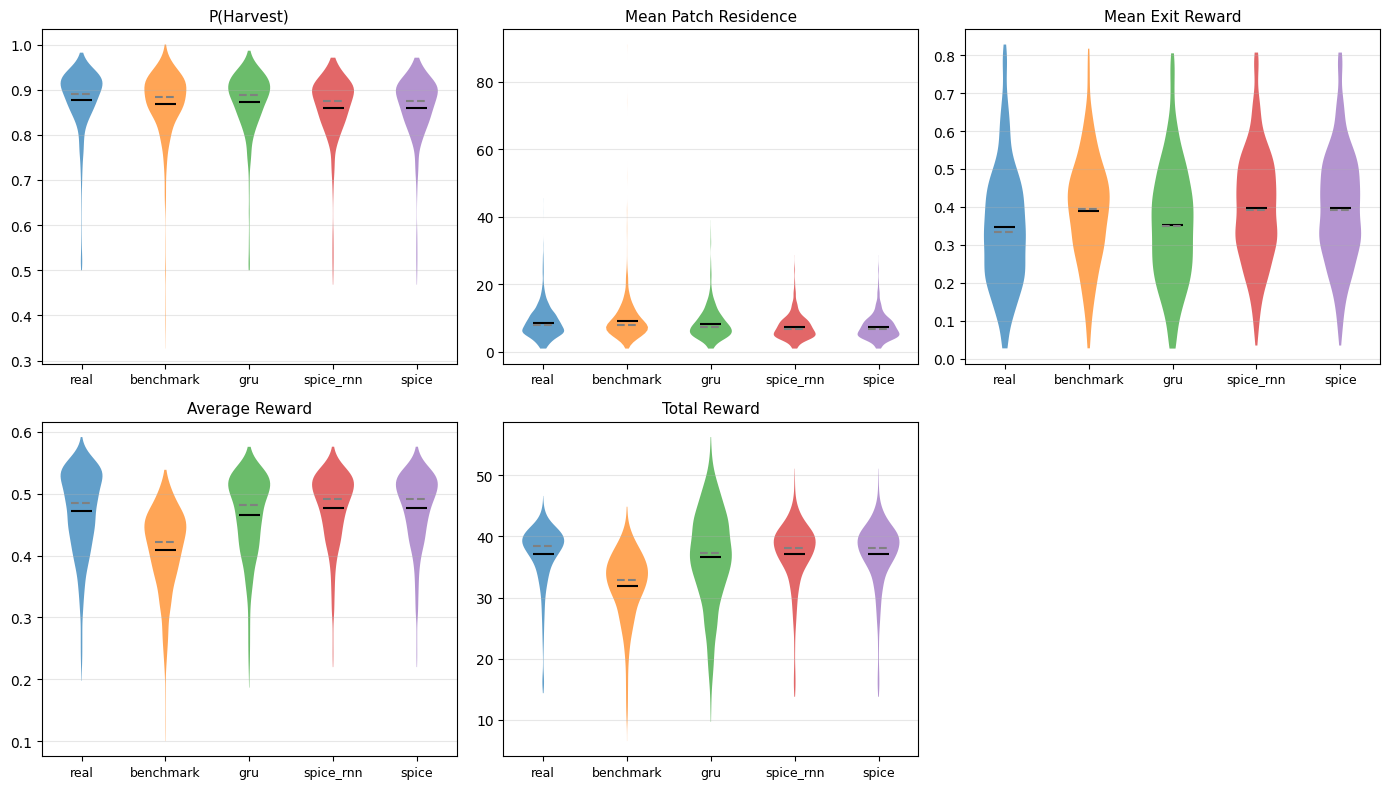


Per-metric MAE (|model_mean - real_mean|):
          P(Harvest) Mean Patch Residence Mean Exit Reward Average Reward  \
Model                                                                       
benchmark     0.0091               0.6038           0.0424         0.0614   
gru           0.0054               0.2967           0.0056         0.0064   
spice_rnn     0.0174               1.2274           0.0496         0.0054   
spice         0.0174               1.2274           0.0496         0.0054   

          Total Reward      Aggregate MAE  
Model                                      
benchmark       5.1424  1.1718 +/- 1.9974  
gru             0.4996  0.1628 +/- 0.2026  
spice_rnn       0.0662  0.2732 +/- 0.4776  
spice           0.0662  0.2732 +/- 0.4776  


(                P(Harvest) Mean Patch Residence Mean Exit Reward  \
 Model                                                              
 real       0.878 +/- 0.074      8.628 +/- 4.596  0.347 +/- 0.161   
 benchmark  0.869 +/- 0.080      9.232 +/- 5.675  0.389 +/- 0.142   
 gru        0.872 +/- 0.073      8.331 +/- 4.690  0.352 +/- 0.157   
 spice_rnn  0.861 +/- 0.073      7.400 +/- 3.766  0.396 +/- 0.148   
 spice      0.861 +/- 0.073      7.400 +/- 3.766  0.396 +/- 0.148   
 
             Average Reward      Total Reward  
 Model                                         
 real       0.471 +/- 0.068  37.080 +/- 4.934  
 benchmark  0.410 +/- 0.067  31.938 +/- 5.765  
 gru        0.465 +/- 0.067  36.581 +/- 7.776  
 spice_rnn  0.477 +/- 0.059  37.146 +/- 5.347  
 spice      0.477 +/- 0.059  37.146 +/- 5.347  ,
           P(Harvest) Mean Patch Residence Mean Exit Reward Average Reward  \
 Model                                                                       
 benchmark     0.0091 

In [25]:
analysis_generative_behavior(
    path_data_real='data/bustamante2023.csv',
    path_data_benchmark='data/bustamante2023_benchmark.csv',
    path_data_gru='data/bustamante2023_gru.csv',
    path_data_spice_rnn='data/bustamante2023_spice.csv',
    path_data_spice='data/bustamante2023_spice.csv',
)

## Analysis coefficient distributions

In [26]:
analysis_coefficients_distributions(
    spice_model=estimator,
    output_dir='results',
)

Extracting coefficient data...
  Ensemble=10, Participants=250, Experiments=1, Modules=6, Total terms=30

ANALYSIS 1: Ensemble Consistency
  Mean presence agreement: 1.000
  Mean presence rate:      0.879
  Mean CV:                 4.692
  Ensemble spread plots saved.
  Ensemble CV heatmaps saved.

ANALYSIS 2: Coefficient Distributions
  Terms with >50% presence: 27 / 30
  Terms with 0% presence:   1 / 30
  Violin plots saved.
  Presence rate bar chart saved.
  Experiment comparison skipped (X=1).
  Sparsity heatmaps saved.

All results saved to: results


(                     module                                term  term_index  \
 0        reward_environment                                   1           0   
 1        reward_environment                  reward_environment           1   
 2        reward_environment                           reward[t]           2   
 3        reward_environment                reward_environment^2           3   
 4        reward_environment        reward_environment*reward[t]           4   
 5        reward_environment                         reward[t]^2           5   
 6      reward_patch_harvest                                   1           0   
 7      reward_patch_harvest                reward_patch_harvest           1   
 8      reward_patch_harvest                           reward[t]           2   
 9      reward_patch_harvest              reward_patch_harvest^2           3   
 10     reward_patch_harvest      reward_patch_harvest*reward[t]           4   
 11     reward_patch_harvest            

## Analysis Individual Differences

In [ ]:
analysis_coefficients_individuals(
    criterion="SomeCriterionColumnInYourDataset",
    analysis="disc",  # also: "cont"
    reference="ReferenceGroupFromCriterionColumn",  # only necessary if analysis="disct"
    
    path_data=path_data,
    
    spice_model=estimator,
    
    dir_output='results'
)

## Analysis generative behavior

In [ ]:
# create violin plots